In [1]:
# Step 1: Forcefully uninstall all related libraries
!pip uninstall -y numpy scipy scikit-learn

# Step 2: Clear the pip cache to ensure a fresh download
!pip cache purge

# Step 3: Reinstall, forcing a recompile if possible
# This tells pip to download fresh source code and try to build it,
# which gives it the best chance of finding your gfortran library.
!pip install --no-cache-dir --force-reinstall scikit-learn

Found existing installation: numpy 2.3.3
Uninstalling numpy-2.3.3:
  Successfully uninstalled numpy-2.3.3
Found existing installation: scipy 1.16.2
Uninstalling scipy-1.16.2:
  Successfully uninstalled scipy-1.16.2
Found existing installation: scikit-learn 1.7.2
Uninstalling scikit-learn-1.7.2:
  Successfully uninstalled scikit-learn-1.7.2
Files removed: 0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 1.7 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 1.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 1.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.2
    Uninstalling joblib-1.5.2:
      Successfully uninstalled joblib-1.5.2
ERROR: pip's dependency resolver does not current

In [6]:
!pip install ipywidgets

In [7]:
import ipywidgets as widgets
from IPython.display import display

# Create the upload button widget
uploader = widgets.FileUpload(
    accept='.csv',  # Accept only .csv files
    description='Upload crop_yield.csv'
)

# Display the button
display(uploader)

FileUpload(value=(), accept='.csv', description='Upload crop_yield.csv')

In [8]:
import pandas as pd
import io

# Check if a file has been uploaded
if uploader.value:
    # Get the first uploaded file from the widget's value
    uploaded_file = uploader.value[0]
    
    # Get the content of the file in bytes
    content = uploaded_file['content']
    
    # Read the bytes into a pandas DataFrame
    df = pd.read_csv(io.BytesIO(content))
    
    print("✅ File uploaded and loaded into 'df' successfully!")
    print("\nDataset preview:")
    print(df.head())
else:
    print("❌ Please upload a file in the cell above first.")

✅ File uploaded and loaded into 'df' successfully!

Dataset preview:
           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           2051.4    75755.32     246.76     0.238333  
3           2051.4  1870661.52    6093.36  5238.051739  
4           2051.4   165500.63     539.09     0.420909  


In [9]:
# Step 3: Inspect the dataset
print(df.info())        # column types + null counts
print(df.describe())    # numeric summary

# Missing values check
print("Missing values per column:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB
None
          Crop_Year          Area    Production  Annual_Rainfall  \
count  19689.000000  1.968900e+04  1.968900e+04     19689.000000   
mean    2009.127584  1.799266e+05  1.643594e+07      1437.755177   
std        6.498099  7.328287e+05  2.630568e+08       816.909589   


In [10]:
# Step 4: Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (19689, 10)


In [11]:
# Step 5: Handle outliers / skewness (log transform some cols)
import numpy as np

skewed_cols = ["Area", "Production", "Annual_Rainfall", "Fertilizer", "Pesticide"]
for col in skewed_cols:
    df[col] = df[col].apply(lambda x: np.log1p(x))   # log(1+x) to handle zeros





In [12]:
# Step 6: Scaling numeric features (except Yield which is target)
from sklearn.preprocessing import StandardScaler

numeric_cols = ["Crop_Year","Area","Production","Annual_Rainfall","Fertilizer","Pesticide"]
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [13]:
# Step 7: Encode categoricals
from sklearn.preprocessing import LabelEncoder

# Encode Crop and State with LabelEncoder
le_crop = LabelEncoder()
df["Crop"] = le_crop.fit_transform(df["Crop"])

le_state = LabelEncoder()
df["State"] = le_state.fit_transform(df["State"])

# One-hot encode Season
df = pd.get_dummies(df, columns=["Season"], drop_first=True)


In [15]:
!pip install seaborn

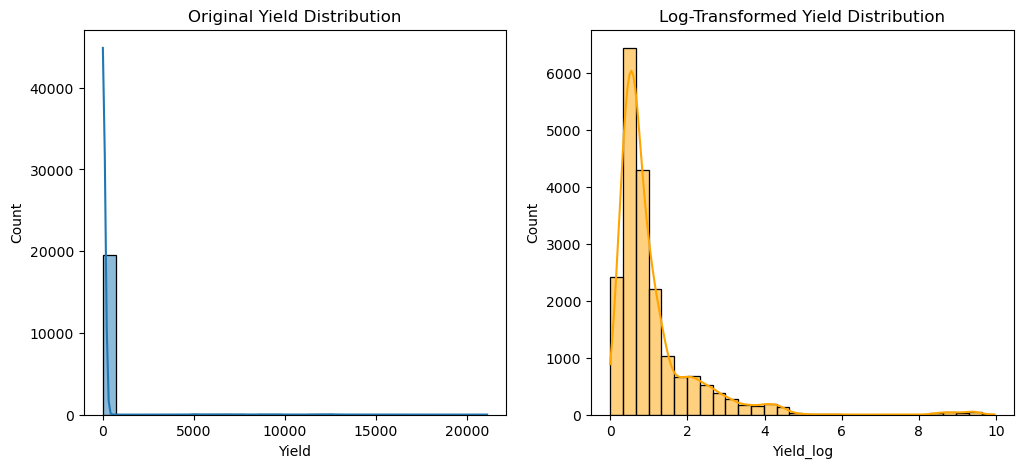

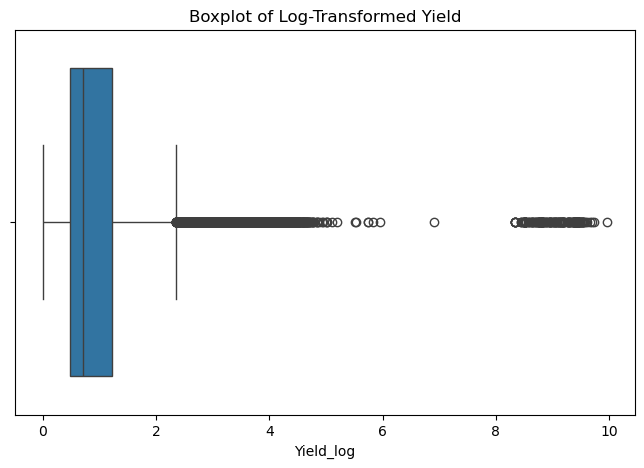

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply log transformation (log(1+Yield) to avoid log(0) issue)
df["Yield_log"] = np.log1p(df["Yield"])

# Compare distributions before vs after
plt.figure(figsize=(12,5))

# Original Yield
plt.subplot(1,2,1)
sns.histplot(df["Yield"], bins=30, kde=True)
plt.title("Original Yield Distribution")

# Log-Transformed Yield
plt.subplot(1,2,2)
sns.histplot(df["Yield_log"], bins=30, kde=True, color="orange")
plt.title("Log-Transformed Yield Distribution")

plt.show()

# Boxplot after log-transform
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Yield_log"])
plt.title("Boxplot of Log-Transformed Yield")
plt.show()

In [17]:
df.to_csv("crop_yield_dataset1.csv", index=False)

In [18]:
df.describe()

,Crop,Crop_Year,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Yield_log
count,19689.000000,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,1.968900e+04,1.968900e+04,1.968900e+04,19689.000000,19689.000000
mean,29.357662,-1.515132e-14,14.328813,3.464478e-17,7.506368e-17,-1.501274e-16,2.078687e-16,-2.887065e-16,79.954009,1.081109
std,15.560857,1.000025e+00,9.000461,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,878.306193,1.135903
min,0.000000,-1.866375e+00,0.000000,-2.927326e+00,-2.713657e+00,-2.833807e+00,-3.346914e+00,-2.623594e+00,0.000000,0.000000
25%,17.000000,-7.891099e-01,7.000000,-6.179458e-01,-6.306812e-01,-5.817010e-01,-6.098729e-01,-6.392473e-01,0.600000,0.470004
50%,31.000000,1.342605e-01,14.000000,2.492111e-02,2.898775e-02,-2.258962e-02,2.350949e-02,1.598619e-02,1.030000,0.708036
75%,43.000000,9.037359e-01,22.000000,7.303603e-01,6.575880e-01,5.235269e-01,7.274440e-01,7.396789e-01,2.388889,1.220502
max,54.000000,1.673211e+00,29.000000,2.933100e+00,3.779285e+00,3.263616e+00,2.807264e+00,3.023123e+00,21105.000000,9.957313


=== Random Forest Performance ===
RMSE: 310.44
R² Score: 0.88

Cross-validation R² Scores: [0.82588121 0.92426983 0.88541638 0.89716191 0.85288086]
Average CV R²: 0.8771220382892885


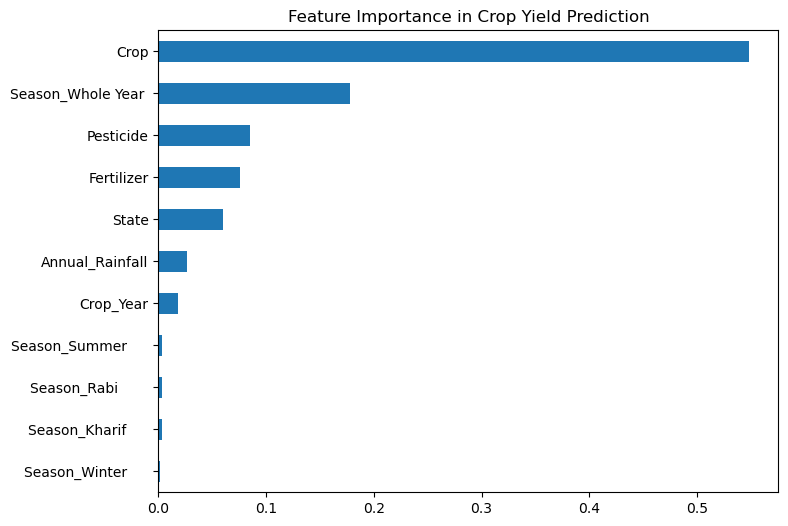

In [19]:
# ==========================
# Crop Yield Prediction - Random Forest
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset
df = pd.read_csv("crop_yield_dataset1.csv")


# 3. Features (all except Yield and Yield_log)
feature_cols = [
    'Crop', 'Crop_Year', 'State', 'Annual_Rainfall', 'Fertilizer', 'Pesticide',   'Season_Kharif     ', 'Season_Rabi       ', 'Season_Summer     ', 'Season_Whole Year ', 'Season_Winter     '
]

X = df[feature_cols]
y = df["Yield_log"]

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Train Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 6. Predictions
y_pred = rf.predict(X_test)

# Convert back from log scale
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

# 7. Evaluation
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print("=== Random Forest Performance ===")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# 8. Cross-validation for stability
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="r2", n_jobs=-1)
print("\nCross-validation R² Scores:", cv_scores)
print("Average CV R²:", cv_scores.mean())

# 9. Feature Importance
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance in Crop Yield Prediction")
plt.show()


In [20]:
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor

# Base model: Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Apply AdaBoost on Random Forest
ada_rf = AdaBoostRegressor(
    estimator=rf,
    n_estimators=50,      # number of boosting rounds
    learning_rate=0.5,
    random_state=42
)

# Train
ada_rf.fit(X_train, y_train)

# Predict
y_pred_ada = ada_rf.predict(X_test)
y_pred_ada_actual = np.expm1(y_pred_ada)

# Evaluate
rmse_ada = np.sqrt(mean_squared_error(y_test_actual, y_pred_ada_actual))
r2_ada = r2_score(y_test_actual, y_pred_ada_actual)

print("=== AdaBoost + Random Forest Performance ===")
print(f"RMSE: {rmse_ada:.2f}")
print(f"R² Score: {r2_ada:.2f}")



=== AdaBoost + Random Forest Performance ===
RMSE: 140.61
R² Score: 0.98


In [21]:
from sklearn.model_selection import cross_val_score

# Cross-validation (use log-transformed target if you trained on it)
cv_scores = cross_val_score(
    ada_rf,
    X, y,            # full dataset
    cv=3,            # reduce folds (lighter on memory)
    scoring="r2",
    n_jobs=1         # run sequentially to avoid worker crash in Colab
)

print("Cross-Validation R² Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())


Cross-Validation R² Scores: [0.85725848 0.88796104 0.82609231]
Mean CV R²: 0.857103940699745


In [22]:
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Base model: Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Apply AdaBoost on Random Forest
ada_rf = AdaBoostRegressor(
    estimator=rf,
    n_estimators=50,      # number of boosting rounds
    learning_rate=0.5,
    random_state=42
)

# ================= Train & Test Evaluation =================
ada_rf.fit(X_train, y_train)

# Predict
y_pred_ada = ada_rf.predict(X_test)
y_pred_ada_actual = np.expm1(y_pred_ada)   # reverse log-transform if applied

# Evaluate
rmse_ada = np.sqrt(mean_squared_error(y_test_actual, y_pred_ada_actual))
r2_ada = r2_score(y_test_actual, y_pred_ada_actual)

print("=== AdaBoost + Random Forest Test Performance ===")
print(f"RMSE: {rmse_ada:.2f}")
print(f"R² Score: {r2_ada:.2f}")

# ================= Cross-Validation =================
cv_scores = cross_val_score(
    ada_rf,
    X, y,
    cv=3,              # use fewer folds for Colab memory stability
    scoring="r2",
    n_jobs=1           # run sequentially to avoid TerminatedWorkerError
)

print("\n=== AdaBoost + Random Forest Cross-Validation ===")
print("R² scores for each fold:", cv_scores)
print("Average R² score:", np.mean(cv_scores))
print("Standard deviation:", np.std(cv_scores))


=== AdaBoost + Random Forest Test Performance ===
RMSE: 140.61
R² Score: 0.98

=== AdaBoost + Random Forest Cross-Validation ===
R² scores for each fold: [0.85725848 0.88796104 0.82609231]
Average R² score: 0.857103940699745
Standard deviation: 0.025258038288007705


In [23]:
!pip install joblib scikit-learn

In [24]:
import joblib

# --- This is the code you run in your notebook ---

# 1. The final AdaBoost model
joblib.dump(ada_rf, 'yield_model_adaboost.pkl')

# 2. The StandardScaler object
joblib.dump(scaler, 'scaler.pkl')

# 3. The LabelEncoder for Crop
joblib.dump(le_crop, 'le_crop.pkl')

# 4. The LabelEncoder for State
joblib.dump(le_state, 'le_state.pkl')

print("✅ Success! The four .pkl files have been created.")

✅ Success! The four .pkl files have been created.
